In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold

Dataset

In [2]:
bm_csv = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv"
bm_df = pd.read_csv(bm_csv)

Data preparation \
Check if the missing values are presented in the features. \
If there are missing values: \
For categorical features, replace them with 'NA' \
For numerical features, replace with with 0.0

In [3]:
bm_df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [4]:
bm_df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [5]:
missing_columns = bm_df.columns[bm_df.isnull().any()]
print(f"Columns with missing values are:{missing_columns.values}")

Columns with missing values are:['lead_source' 'industry' 'annual_income' 'employment_status' 'location']


In [6]:
bm_df.columns

Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score',
       'converted'],
      dtype='object')

In [7]:
# replace with NA
def fill_categorical(df, column):
    return df[column].fillna(value="NA")

In [8]:
# replace with 0.0
def fill_numerical(df, column):
    return df[column].fillna(value=0.0)

In [9]:
categorical_features = list(bm_df.select_dtypes(include=["object"]).columns)

for column_missing in missing_columns:
    if column_missing in categorical_features:
        bm_df[column_missing] = fill_categorical(bm_df, column_missing)
    else:
        bm_df[column_missing] = fill_numerical(bm_df, column_missing)

In [10]:
missing_columns = bm_df.columns[bm_df.isnull().any()]
print(f"Columns with missing values are:{missing_columns.values}")

Columns with missing values are:[]


In [11]:
bm_df.head(10)

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NA,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NA,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
5,events,manufacturing,1,59904.0,NA,africa,6,0.83,1
6,social_media,technology,0,51283.0,NA,middle_east,2,0.57,0
7,social_media,NA,5,62975.0,student,europe,4,0.62,1
8,referral,healthcare,4,38648.0,unemployed,south_america,2,0.86,1
9,paid_ads,other,3,59866.0,student,australia,3,0.43,1


In [12]:
bm_df.converted.value_counts(normalize=True)*100

converted
1    61.901505
0    38.098495
Name: proportion, dtype: float64

Split the data \
Split your data in train/val/test sets with 60%/20%/20% distribution. \
Use Scikit-Learn for that (the train_test_split function) and set the seed to 1. \
Make sure that the target value y is not in your dataframe.

Changing how the split is made modifies obtained results not much but you can see a slight difference

In [13]:
#train, test_vldtn = train_test_split(bm_df, test_size=0.4, random_state=1)
#vldtn, test = train_test_split(test_vldtn, test_size=0.5, random_state=1)
#print(len(train))
#print(len(vldtn))
#print(len(test))

In [14]:
train_f, test = train_test_split(bm_df, test_size=0.2, random_state=1)
train, vldtn = train_test_split(train_f, test_size=0.25, random_state=1)
print(len(train))
print(len(vldtn))
print(len(test))

876
293
293


You can also check each of the splits to see how classes are distributed

In [15]:
train.converted.value_counts(normalize=True)*100

converted
1    62.100457
0    37.899543
Name: proportion, dtype: float64

In [16]:
vldtn.converted.value_counts(normalize=True)*100

converted
1    58.361775
0    41.638225
Name: proportion, dtype: float64

In [17]:
test.converted.value_counts(normalize=True)*100

converted
1    64.846416
0    35.153584
Name: proportion, dtype: float64

In [18]:
train = train.reset_index(drop=True)
vldtn = vldtn.reset_index(drop=True)
test = test.reset_index(drop=True)

y_train = train.converted.values
y_vldtn = vldtn.converted.values
y_test = test.converted.values

del train["converted"]
del vldtn["converted"]
del test["converted"]

Question 1: ROC AUC feature importance \
ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that \
For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth. \
Use the training dataset for that \
If your AUC is < 0.5, invert this variable by putting "-" in front (e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

In [19]:
nmrc_ftrs = list(train.select_dtypes(include="number").columns)
nmrc_ftrs

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

In [20]:
# get roc_auc_score using ovr in multiclass
def get_auc_ftr_imprtnc_ovr(train_df, feature, y_actual):
    score = roc_auc_score(y_actual, train_df[feature], multi_class="ovr")
    #if score is < 0.5 invert feature
    if score < 0.5:
        print(f"Inverting feature: {feature}")
        score = score = roc_auc_score(y_actual, -train_df[feature], multi_class="ovr")
    return score

In [21]:
roc_auc_scores_ovr = {}
for ftr in nmrc_ftrs:
    roc_auc_scores_ovr[ftr] = get_auc_ftr_imprtnc_ovr(train, ftr, y_train)

In [22]:
hghst_auc_score = max(roc_auc_scores_ovr, key=roc_auc_scores_ovr.get)
print(f"Feature with highest roc_auc_score is: {hghst_auc_score}")

Feature with highest roc_auc_score is: number_of_courses_viewed


In [23]:
# get roc_auc_score using ovo in multiclass
def get_auc_ftr_imprtnc_ovo(train_df, feature, y_actual):
    score = roc_auc_score(y_actual, train_df[feature], multi_class="ovo")
    #if score is < 0.5 invert feature
    if score < 0.5:
        print(f"Inverting feature: {feature}")
        score = score = roc_auc_score(y_actual, -train_df[feature], multi_class="ovo")
    return score

In [24]:
roc_auc_scores_ovo = {}
for ftr in nmrc_ftrs:
    roc_auc_scores_ovo[ftr] = get_auc_ftr_imprtnc_ovo(train, ftr, y_train)

In [25]:
hghst_auc_score = max(roc_auc_scores_ovo, key=roc_auc_scores_ovo.get)
print(f"Feature with highest roc_auc_score is: {hghst_auc_score}")

Feature with highest roc_auc_score is: number_of_courses_viewed


Question 2: Training the model \
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

What's the AUC of this model on the validation dataset? (round to 3 digits)

In [26]:
ctgrcl_ftrs = list(bm_df.select_dtypes(include=["object"]).columns)

In [27]:
train.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
dtype: object

In [28]:
vldtn.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
dtype: object

In [29]:
def get_auc_lg_rgrssn(train_df, vldtn_df, train_y, vldtn_y):
    auc_score = 0.0
    dct_vctrzr = DictVectorizer(sparse=False)
    #get dict of features
    train_dct = train_df[ctgrcl_ftrs + nmrc_ftrs].to_dict(orient="records")
    vldtn_dct = vldtn_df[ctgrcl_ftrs + nmrc_ftrs].to_dict(orient="records")
    #map feature names
    dct_vctrzr.fit(train_dct)
    #get numerical feature matrix
    X_train = dct_vctrzr.transform(train_dct)
    X_vldtn = dct_vctrzr.transform(vldtn_dct)
    #train logistic regression
    lg_rg = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000)
    lg_rg.fit(X_train, train_y)
    #predict using model
    y_prdctd = lg_rg.predict_proba(X_vldtn)[:, 1]
    #get roc_auc_score
    auc_score = roc_auc_score(vldtn_y, y_prdctd)
    return auc_score, y_prdctd

This is the result with suggested model parameters and not scaling

In [30]:
auc_on_vldtn_unscld, y_prdctd_unscld = get_auc_lg_rgrssn(train, vldtn, y_train, y_vldtn)
#print(f"AUC of model is: {np.round(auc_on_vldtn_unscld, 3)}")
print(f"AUC of model is: {auc_on_vldtn_unscld}")
options = [0.72, 0.92]
print(f"Closest value is: {min(options, key=lambda score: auc_on_vldtn_unscld - score)}")

AUC of model is: 0.8171316268814112
Closest value is: 0.92


In [31]:
def get_auc_lg_rgrssn_scld(train_df, vldtn_df, train_y, vldtn_y):
    auc_score = 0.0
    dct_vctrzr = DictVectorizer(sparse=False)
    #scale numeric features
    scaler = StandardScaler()
    X_train_nmrc = train_df[nmrc_ftrs].values
    X_train_nmrc = scaler.fit_transform(X_train_nmrc)
    X_vldtn_nmrc = vldtn_df[nmrc_ftrs].values
    X_vldtn_nmrc = scaler.fit_transform(X_vldtn_nmrc)
    #get dict of features
    train_dct = train_df[ctgrcl_ftrs].to_dict(orient="records")
    vldtn_dct = vldtn_df[ctgrcl_ftrs].to_dict(orient="records")
    #map feature names
    dct_vctrzr.fit(train_dct)
    #get numerical feature matrix
    X_train_ctgrcl = dct_vctrzr.transform(train_dct)
    X_vldtn_ctgrcl = dct_vctrzr.transform(vldtn_dct)
    #combine preprocessed features
    X_train = np.column_stack([X_train_nmrc, X_train_ctgrcl])
    X_vldtn = np.column_stack([X_vldtn_nmrc, X_vldtn_ctgrcl])
    #train logistic regression
    lg_rg = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000)
    lg_rg.fit(X_train, train_y)
    #predict using model
    y_prdctd = lg_rg.predict_proba(X_vldtn)[:, 1]
    #get roc_auc_score
    auc_score = roc_auc_score(vldtn_y, y_prdctd)
    return auc_score, y_prdctd

This is the result with suggested model parameters and scaling, just recall that the question has specific instructions, this is just to compare

In [32]:
auc_on_vldtn_scld, y_prdctd_scld = get_auc_lg_rgrssn_scld(train, vldtn, y_train, y_vldtn)
print(f"AUC of model is: {np.round(auc_on_vldtn_scld, 3)}")
print(f"Closest value is: {min(options, key=lambda score: auc_on_vldtn_scld - score)}")

AUC of model is: 0.92
Closest value is: 0.92


Question 3: Precision and Recall \
Now let's compute precision and recall for our model.

Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01 \
For each threshold, compute precision and recall \
Plot them \
At which threshold precision and recall curves intersect?

In [33]:
thresholds = np.linspace(0.0, 1.0, 101)
thresholds

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [34]:
thresholds = np.linspace(0, 1.0, 101)

scores_unscld = []
scores_scld = []
prcsn_unscld = 0
prcsn_scld = 0
rcll_unscld = 0
rcll_scld = 0

actual_positive = (y_vldtn == 1)
actual_negative = (y_vldtn == 0)

for treshold in thresholds:
    predict_positive_unscld = (y_prdctd_unscld >= treshold)
    predict_negative_unscld = (y_prdctd_unscld < treshold)

    predict_positive_scld = (y_prdctd_scld >= treshold)
    predict_negative_scld = (y_prdctd_scld < treshold)

    tp_unscld = (predict_positive_unscld & actual_positive).sum()
    tn_unscld = (predict_negative_unscld & actual_negative).sum()
    fp_unscld = (predict_positive_unscld & actual_negative).sum()
    fn_unscld = (predict_negative_unscld & actual_positive).sum()

    tp_scld = (predict_positive_scld & actual_positive).sum()
    tn_scld = (predict_negative_scld & actual_negative).sum()
    fp_scld = (predict_positive_scld & actual_negative).sum()
    fn_scld = (predict_negative_scld & actual_positive).sum()

    if tp_unscld + fp_unscld == 0:
        prcsn_unscld = np.nan
    else:
        prcsn_unscld = tp_unscld / (tp_unscld + fp_unscld)
    
    if tp_scld + fp_scld == 0:
        prcsn_scld = np.nan
    else:
        prcsn_scld = tp_scld / (tp_scld + fp_scld)

    rcll_unscld = tp_unscld / (tp_unscld + fn_unscld)
    rcll_scld = tp_scld / (tp_scld + fn_scld)

    scores_unscld.append((treshold, tp_unscld, fp_unscld, fn_unscld, tn_unscld, prcsn_unscld, rcll_unscld))
    scores_scld.append((treshold, tp_scld, fp_scld, fn_scld, tn_scld, prcsn_scld, rcll_scld))

In [35]:
columns = ["threshold", "tp", "fp", "fn", "tn", "precision", "recall"]
prec_recall_scores_unscld = pd.DataFrame(scores_unscld, columns=columns)
prec_recall_scores_unscld

,threshold,tp,fp,fn,tn,precision,recall
0,0.00,171,122,0,0,0.583618,1.000000
1,0.01,171,122,0,0,0.583618,1.000000
2,0.02,171,122,0,0,0.583618,1.000000
3,0.03,171,122,0,0,0.583618,1.000000
4,0.04,171,122,0,0,0.583618,1.000000
...,...,...,...,...,...,...,...
96,0.96,3,0,168,122,1.000000,0.017544
97,0.97,1,0,170,122,1.000000,0.005848
98,0.98,0,0,171,122,NaN,0.000000
99,0.99,0,0,171,122,NaN,0.000000


In [36]:
prec_recall_scores_unscld["prec_rcll_diff"] = np.abs(prec_recall_scores_unscld["precision"]-prec_recall_scores_unscld["recall"])
prec_recall_scores_unscld

,threshold,tp,fp,fn,tn,precision,recall,prec_rcll_diff
0,0.00,171,122,0,0,0.583618,1.000000,0.416382
1,0.01,171,122,0,0,0.583618,1.000000,0.416382
2,0.02,171,122,0,0,0.583618,1.000000,0.416382
3,0.03,171,122,0,0,0.583618,1.000000,0.416382
4,0.04,171,122,0,0,0.583618,1.000000,0.416382
...,...,...,...,...,...,...,...,...
96,0.96,3,0,168,122,1.000000,0.017544,0.982456
97,0.97,1,0,170,122,1.000000,0.005848,0.994152
98,0.98,0,0,171,122,NaN,0.000000,NaN
99,0.99,0,0,171,122,NaN,0.000000,NaN


In [37]:
scores_unscld = dict(zip(prec_recall_scores_unscld["threshold"], prec_recall_scores_unscld["prec_rcll_diff"]))
intrsctn_threshold = min(scores_unscld, key=scores_unscld.get)
intrsctn_threshold

0.64

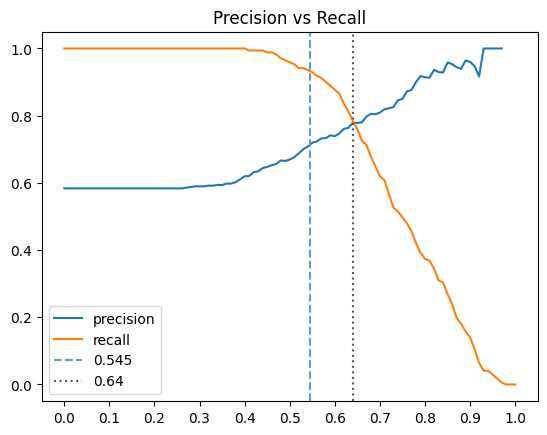

In [38]:
plt.plot(prec_recall_scores_unscld.threshold, prec_recall_scores_unscld["precision"], label="precision")
plt.plot(prec_recall_scores_unscld.threshold, prec_recall_scores_unscld["recall"], label="recall")
plt.axvline(x=0.545, color="#5F9ED1", label="0.545", linestyle="--")
plt.axvline(x=intrsctn_threshold, color="#595959", label=str(intrsctn_threshold), linestyle="dotted")
x_tcks = np.linspace(0, 1.0, 11)
x_tcks = np.round(x_tcks, 1)
plt.xticks(x_tcks)
plt.legend()
plt.title("Precision vs Recall")
plt.show()

In [39]:
columns = ["threshold", "tp", "fp", "fn", "tn", "precision", "recall"]
prec_recall_scores_scld = pd.DataFrame(scores_scld, columns=columns)
prec_recall_scores_scld

,threshold,tp,fp,fn,tn,precision,recall
0,0.00,171,122,0,0,0.583618,1.000000
1,0.01,171,116,0,6,0.595819,1.000000
2,0.02,171,110,0,12,0.608541,1.000000
3,0.03,170,108,1,14,0.611511,0.994152
4,0.04,170,104,1,18,0.620438,0.994152
...,...,...,...,...,...,...,...
96,0.96,64,0,107,122,1.000000,0.374269
97,0.97,59,0,112,122,1.000000,0.345029
98,0.98,49,0,122,122,1.000000,0.286550
99,0.99,39,0,132,122,1.000000,0.228070


In [40]:
prec_recall_scores_scld["prec_rcll_diff"] = np.abs(prec_recall_scores_scld["precision"]-prec_recall_scores_scld["recall"])

In [41]:
scores_scld = dict(zip(prec_recall_scores_scld["threshold"], prec_recall_scores_scld["prec_rcll_diff"]))
intrsctn_threshold = min(scores_scld, key=scores_scld.get)
intrsctn_threshold

0.53

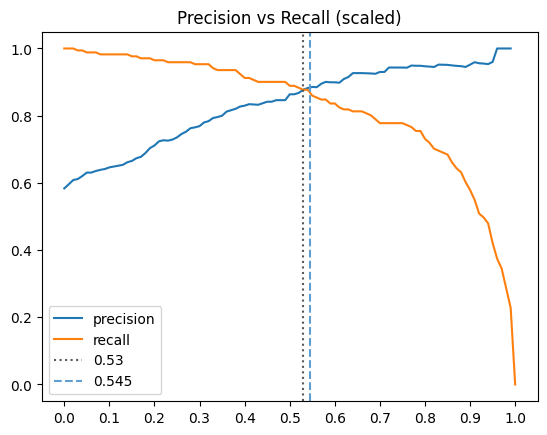

In [42]:
plt.plot(prec_recall_scores_scld.threshold, prec_recall_scores_scld["precision"], label="precision")
plt.plot(prec_recall_scores_scld.threshold, prec_recall_scores_scld["recall"], label="recall")
plt.axvline(x=intrsctn_threshold, color="#595959", label=str(intrsctn_threshold), linestyle="dotted")
plt.axvline(x=0.545, color="#5F9ED1", label="0.545", linestyle="--")
plt.xticks(x_tcks)
plt.title("Precision vs Recall (scaled)")
plt.legend()
plt.show()

For unscaled data the treshold where the intersection 'seems' to occur is close to ~0.62

as for scaled data is close to ~0.51

Question 4: F1 score
Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

F1=2⋅[(P⋅R)/(P+R)]

Where P is precision and R is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

In [43]:
def get_f1_score(scores_df):
    prcsn = scores_df["precision"]
    rcll = scores_df["recall"]
    if prcsn + rcll == 0:
        #should i return nan instead or does not matter?
        return 0
    else:
        return 2*((prcsn*rcll)/(prcsn+rcll))

In [44]:
prec_recall_scores_unscld["f1_score"] = prec_recall_scores_unscld.apply(
    get_f1_score, axis=1
)

In [45]:
prec_recall_scores_unscld

,threshold,tp,fp,fn,tn,precision,recall,prec_rcll_diff,f1_score
0,0.00,171,122,0,0,0.583618,1.000000,0.416382,0.737069
1,0.01,171,122,0,0,0.583618,1.000000,0.416382,0.737069
2,0.02,171,122,0,0,0.583618,1.000000,0.416382,0.737069
3,0.03,171,122,0,0,0.583618,1.000000,0.416382,0.737069
4,0.04,171,122,0,0,0.583618,1.000000,0.416382,0.737069
...,...,...,...,...,...,...,...,...,...
96,0.96,3,0,168,122,1.000000,0.017544,0.982456,0.034483
97,0.97,1,0,170,122,1.000000,0.005848,0.994152,0.011628
98,0.98,0,0,171,122,NaN,0.000000,NaN,NaN
99,0.99,0,0,171,122,NaN,0.000000,NaN,NaN


In [46]:
prec_recall_scores_unscld.sort_values(by="f1_score", ascending=False)[["threshold", "precision", "recall", "f1_score"]].head(1)

,threshold,precision,recall,f1_score
57,0.57,0.732394,0.912281,0.8125


In [47]:
prec_recall_scores_scld["f1_score"] = prec_recall_scores_scld.apply(
    get_f1_score, axis=1
)

In [48]:
prec_recall_scores_scld

,threshold,tp,fp,fn,tn,precision,recall,prec_rcll_diff,f1_score
0,0.00,171,122,0,0,0.583618,1.000000,0.416382,0.737069
1,0.01,171,116,0,6,0.595819,1.000000,0.404181,0.746725
2,0.02,171,110,0,12,0.608541,1.000000,0.391459,0.756637
3,0.03,170,108,1,14,0.611511,0.994152,0.382641,0.757238
4,0.04,170,104,1,18,0.620438,0.994152,0.373714,0.764045
...,...,...,...,...,...,...,...,...,...
96,0.96,64,0,107,122,1.000000,0.374269,0.625731,0.544681
97,0.97,59,0,112,122,1.000000,0.345029,0.654971,0.513043
98,0.98,49,0,122,122,1.000000,0.286550,0.713450,0.445455
99,0.99,39,0,132,122,1.000000,0.228070,0.771930,0.371429


In [49]:
prec_recall_scores_scld.sort_values(by="f1_score", ascending=False)[["threshold", "precision", "recall", "f1_score"]].head(1)

,threshold,precision,recall,f1_score
54,0.54,0.882353,0.877193,0.879765


For the f1-score the closest value I got is ~0.54 for unscaled and scaled data

Question 5: 5-Fold CV \
Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

KFold(n_splits=5, shuffle=True, random_state=1) \
Iterate over different folds of df_full_train \
Split the data into train and validation \
Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000) \
Use AUC to evaluate the model on validation \
How large is standard deviation of the scores across different folds?

In [50]:
nmrc_ftrs

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

In [51]:
def train_lg_rgrssn(df_train, y_train, C=1.0):
    dctnrs = df_train[ctgrcl_ftrs + nmrc_ftrs].to_dict(orient='records')

    dct_vctrzr = DictVectorizer(sparse=False)
    X_train = dct_vctrzr.fit_transform(dctnrs)

    lg_rgrssn = LogisticRegression(solver="liblinear", C=C, max_iter=1000, random_state=1)
    lg_rgrssn.fit(X_train, y_train)
    
    return dct_vctrzr, lg_rgrssn

In [52]:
def predict(df, dct_vctrzr, model):
    dicts = df[ctgrcl_ftrs + nmrc_ftrs].to_dict(orient='records')

    X_vldtn_tst = dct_vctrzr.transform(dicts)
    prdctd_y = model.predict_proba(X_vldtn_tst)[:, 1]

    return prdctd_y

In [53]:
#split into train and validation
train_full_df, df_test = train_test_split(bm_df, test_size=0.2, random_state=1)

n_folds = 5

k_fold = KFold(n_splits=n_folds, shuffle=True, random_state=1)
auc_scores = []

n_folds = 0
for train_idx, vldtn_idx in k_fold.split(train_full_df):
    train_df = train_full_df.iloc[train_idx]
    vldtn_df = train_full_df.iloc[vldtn_idx]

    train_y = train_df.converted.values
    vldtn_y = vldtn_df.converted.values

    dct_vctrzr, lg_rgrssn = train_lg_rgrssn(train_df, train_y)
    y_prdctd = predict(vldtn_df, dct_vctrzr, lg_rgrssn)

    auc_score = roc_auc_score(vldtn_y, y_prdctd)
    auc_scores.append(auc_score)

    print(f"Fold #{np.abs(n_folds)}, scores_mean:{np.mean(auc_scores)}, scores_std:{np.std(auc_scores)}")
    n_folds += 1

print(f"\nstd across folds: \t\t{np.std(auc_scores)}")
print(f"std across folds rounded: \t{np.round(np.std(auc_scores), 2)}")

Fold #0, scores_mean:0.8060745924216483, scores_std:0.0
Fold #1, scores_mean:0.8387242146563633, scores_std:0.032649622234715014
Fold #2, scores_mean:0.8176268137326468, scores_std:0.04001082194671579
Fold #3, scores_mean:0.8136793257415772, scores_std:0.03531851340243189
Fold #4, scores_mean:0.8221089148573075, scores_std:0.03580711942905165

std across folds: 		0.03580711942905165
std across folds rounded: 	0.04


In this case my answer is close to ~0.04

Question 6: Hyperparameter Tuning \
Now let's use 5-Fold cross-validation to find the best parameter C

Iterate over the following C values: [0.000001, 0.001, 1] \
Initialize KFold with the same parameters as previously \
Use these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000) \
Compute the mean score as well as the std (round the mean and std to 3 decimal digits) \
Which C leads to the best mean score?

In [54]:
train_full_df, df_test = train_test_split(bm_df, test_size=0.2, random_state=1)

n_folds = 5

for c in [0.000001, 0.001, 1]:
    k_fold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, vldtn_idx in k_fold.split(train_full_df):
        train_df = train_full_df.iloc[train_idx]
        vldtn_df = train_full_df.iloc[vldtn_idx]

        train_y = train_df.converted.values
        vldtn_y = vldtn_df.converted.values

        dct_vctrzr, lg_rgrssn = train_lg_rgrssn(train_df, train_y, C=c)
        y_prdctd = predict(vldtn_df, dct_vctrzr, lg_rgrssn)

        auc_score = roc_auc_score(vldtn_y, y_prdctd)
        auc_scores.append(auc_score)

    print(f"C:{c:.6f}, scores_mean:{np.round(np.mean(auc_scores), 3)}, scores_std:{np.round(np.std(auc_scores), 3)}")

C:0.000001, scores_mean:0.56, scores_std:0.021
C:0.001000, scores_mean:0.868, scores_std:0.022
C:1.000000, scores_mean:0.823, scores_std:0.018


Best mean_score for me is C=0.001

This is just a test as in the lecture notebook

In [55]:
dct_vctrzr, lg_rgrssn = train_lg_rgrssn(train_full_df, train_full_df.converted)
y_prdctd = predict(df_test, dct_vctrzr, lg_rgrssn)

auc_score = roc_auc_score(df_test.converted, y_prdctd)
auc_score

0.8172202350536536